<a href="https://www.kaggle.com/code/omborse771924/student-productivity-dataset-eda?scriptVersionId=330095407" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/velvetcrystal/student-productivity-dataset/Student_Productivity_Dataset.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/velvetcrystal/student-productivity-dataset/Student_Productivity_Dataset.csv')

In [3]:
df.head()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


In [4]:
df.tail()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
9995,9996,23.0,Female,4.2,5.5,5.2,1.6,95.5,100.0,6.6,5.0,7.7,8.5,Average,No,9.0,6.3,6.51,80.59,High
9996,9997,24.0,Male,7.1,6.7,4.0,3.2,64.3,74.5,4.0,0.5,6.8,9.4,Good,Yes,7.0,7.1,6.97,62.95,Medium
9997,9998,24.0,Male,6.4,4.4,6.7,3.3,74.1,100.0,10.0,4.5,5.4,1.0,Average,No,0.0,8.2,1.80,43.79,Low
9998,9999,19.0,Male,8.1,6.8,3.5,4.1,59.5,85.9,7.2,4.6,5.0,5.8,Poor,Yes,4.1,3.5,5.24,49.48,Medium
9999,10000,18.0,Male,4.6,7.2,6.8,3.1,66.0,32.1,7.4,2.3,6.4,9.2,Good,No,7.2,4.0,5.54,62.81,Medium


In [5]:
df.describe()

,Student_ID,Age,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score
count,10000.00000,9845.000000,9835.000000,9894.000000,9868.000000,9920.000000,9878.000000,9882.000000,9815.000000,9863.000000,9846.000000,9825.000000,9822.000000,9860.000000,9839.000000,10000.000000
mean,5000.50000,20.134891,4.219583,6.976602,6.047862,3.032107,79.817301,74.251872,5.991218,3.200862,5.542840,5.957924,4.050204,5.544726,6.489753,54.607333
std,2886.89568,2.497517,1.950639,1.303614,2.424031,1.729774,12.348369,16.588029,2.150297,2.252450,2.107599,2.111982,2.367947,3.892723,1.580462,12.340640
min,1.00000,16.000000,0.000000,3.000000,1.000000,0.000000,40.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,18.000000,2.800000,6.100000,4.300000,1.800000,71.200000,62.900000,4.500000,1.600000,4.100000,4.500000,2.300000,2.700000,5.415000,46.640000
50%,5000.50000,20.000000,4.200000,7.000000,6.000000,3.000000,80.200000,74.900000,6.000000,2.700000,5.600000,6.000000,4.000000,4.700000,6.500000,54.935000
75%,7500.25000,22.000000,5.600000,7.900000,7.700000,4.200000,89.100000,86.800000,7.500000,4.300000,7.000000,7.400000,5.700000,7.500000,7.590000,63.032500
max,10000.00000,25.000000,12.000000,10.000000,14.800000,9.700000,100.000000,100.000000,10.000000,15.000000,10.000000,10.000000,10.000000,25.000000,10.000000,100.000000


In [6]:
df.isnull()

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

Student_ID                            0
Age                                 155
Gender                              119
Study_Hours_Per_Day                 165
Sleep_Hours_Per_Night               106
Screen_Time_Hours                   132
Social_Media_Hours                   80
Attendance_Percentage               122
Assignments_Completed               118
Class_Participation_Score           185
Physical_Activity_Hours_Per_Week    137
Stress_Level                        154
Motivation_Level                    175
Internet_Quality                    149
Part_Time_Job                       126
Extracurricular_Involvement         178
AI_Tool_Usage_Hours_Per_Week        140
Previous_Semester_GPA               161
Productivity_Score                    0
Performance_Category                  0
dtype: int64

In [8]:
# ============================================================
# SEPARATE NUMERIC AND CATEGORICAL COLUMNS
# ============================================================


numeric_cols = df.select_dtypes(
    include=["int64","float64"]
).columns



categorical_cols = df.select_dtypes(
    include=["object"]
).columns







# ============================================================
# REMOVE TARGET FROM FILLING LIST
# ============================================================

target_cols=[

"Productivity_Score",

"Performance_Category"

]



numeric_cols = [

col for col in numeric_cols

if col not in target_cols

]



categorical_cols = [

col for col in categorical_cols

if col not in target_cols

]









# ============================================================
# NUMERIC NULL VALUES
# Median Filling
# ============================================================


for col in numeric_cols:


    df[col] = df[col].fillna(

        df[col].median()

    )










# ============================================================
# CATEGORICAL NULL VALUES
# Mode Filling
# ============================================================


for col in categorical_cols:


    df[col] = df[col].fillna(

        df[col].mode()[0]

    )










# ============================================================
# CHECK AFTER CLEANING
# ============================================================


print("\nAfter Handling Missing Values")


print(

    df.isnull().sum()

)






print(

    "\nTotal Remaining Null Values:",

    df.isnull().sum().sum()

)







# ============================================================
# FINAL DATA INFO
# ============================================================


print(df.info())


display(df.head())


After Handling Missing Values
Student_ID                          0
Age                                 0
Gender                              0
Study_Hours_Per_Day                 0
Sleep_Hours_Per_Night               0
Screen_Time_Hours                   0
Social_Media_Hours                  0
Attendance_Percentage               0
Assignments_Completed               0
Class_Participation_Score           0
Physical_Activity_Hours_Per_Week    0
Stress_Level                        0
Motivation_Level                    0
Internet_Quality                    0
Part_Time_Job                       0
Extracurricular_Involvement         0
AI_Tool_Usage_Hours_Per_Week        0
Previous_Semester_GPA               0
Productivity_Score                  0
Performance_Category                0
dtype: int64

Total Remaining Null Values: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  D

,Student_ID,Age,Gender,Study_Hours_Per_Day,Sleep_Hours_Per_Night,Screen_Time_Hours,Social_Media_Hours,Attendance_Percentage,Assignments_Completed,Class_Participation_Score,Physical_Activity_Hours_Per_Week,Stress_Level,Motivation_Level,Internet_Quality,Part_Time_Job,Extracurricular_Involvement,AI_Tool_Usage_Hours_Per_Week,Previous_Semester_GPA,Productivity_Score,Performance_Category
0,1,19.0,Male,2.6,5.9,7.4,2.8,86.3,75.1,3.8,2.8,1.4,6.3,Poor,No,4.9,16.4,5.88,51.16,Medium
1,2,25.0,Male,5.4,6.4,6.4,4.1,93.3,99.6,7.9,0.5,8.3,8.2,Good,No,3.9,2.1,6.62,74.10,High
2,3,22.0,Male,6.8,5.5,7.4,4.3,66.3,75.6,4.0,1.7,9.3,4.1,Average,No,4.9,3.6,7.11,34.63,Low
3,4,21.0,Female,1.7,8.0,6.2,2.4,62.8,51.9,3.0,2.5,2.5,10.0,Poor,No,2.8,8.5,6.85,53.20,Medium
4,5,17.0,Male,7.6,6.2,4.3,3.7,87.9,37.0,8.8,3.3,6.1,8.0,Average,No,4.5,5.3,5.86,57.40,Medium


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Study_Hours_Per_Day',
       'Sleep_Hours_Per_Night', 'Screen_Time_Hours', 'Social_Media_Hours',
       'Attendance_Percentage', 'Assignments_Completed',
       'Class_Participation_Score', 'Physical_Activity_Hours_Per_Week',
       'Stress_Level', 'Motivation_Level', 'Internet_Quality', 'Part_Time_Job',
       'Extracurricular_Involvement', 'AI_Tool_Usage_Hours_Per_Week',
       'Previous_Semester_GPA', 'Productivity_Score', 'Performance_Category'],
      dtype='object')

## EDA

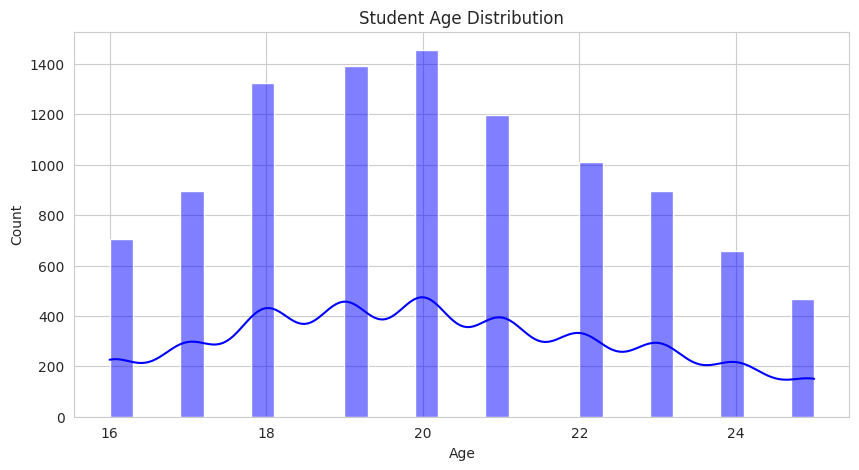

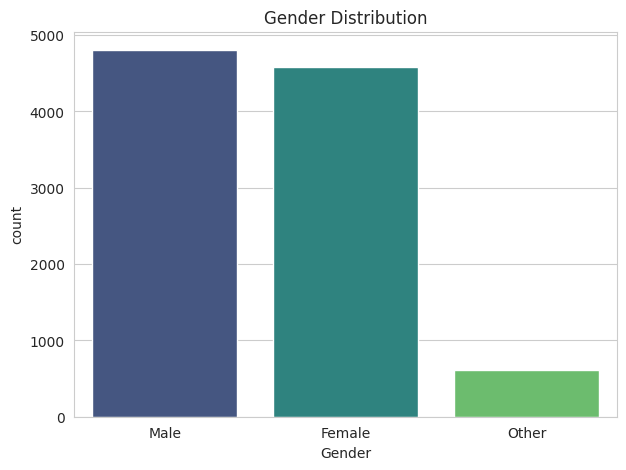

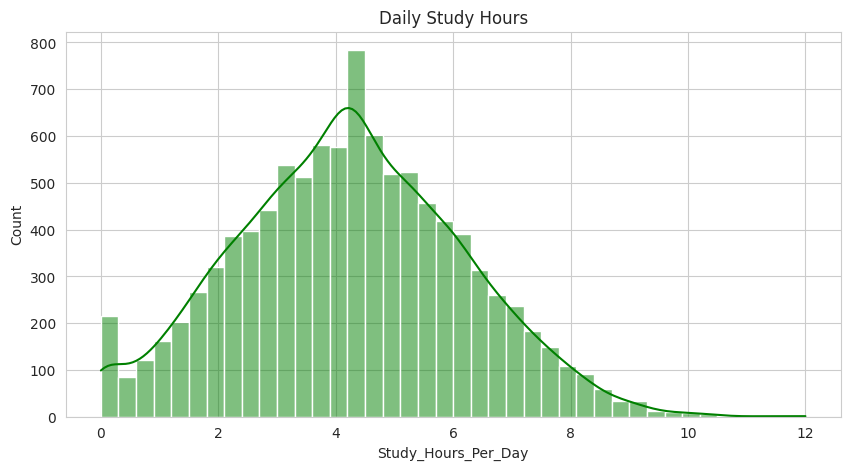

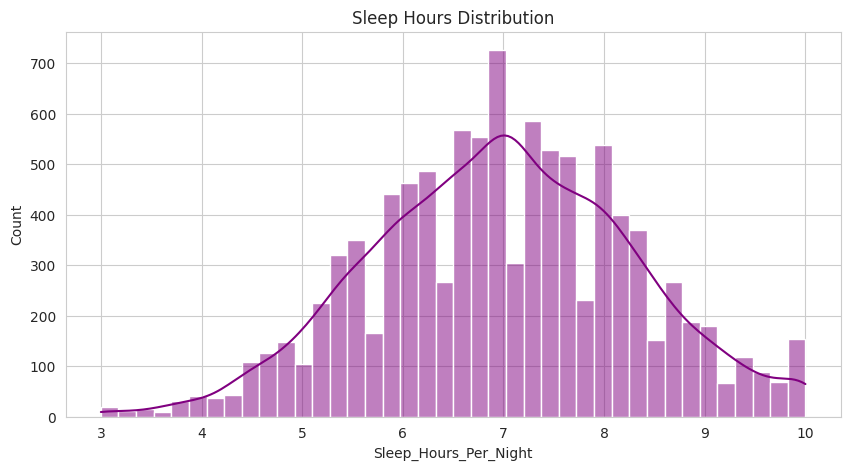

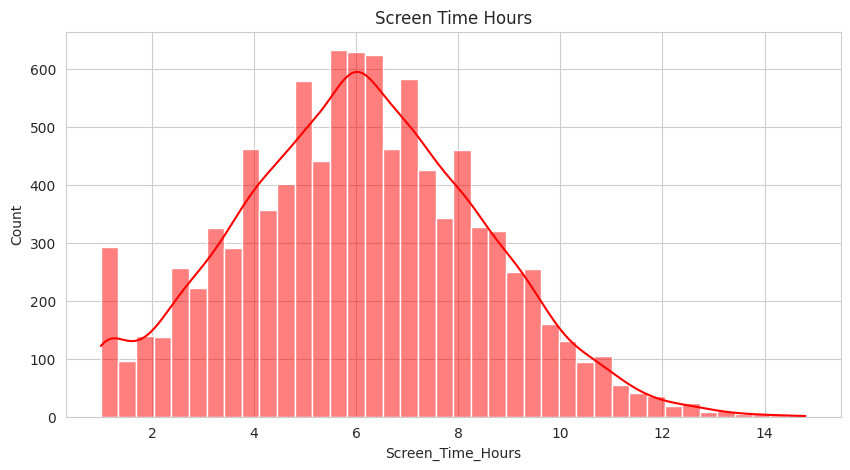

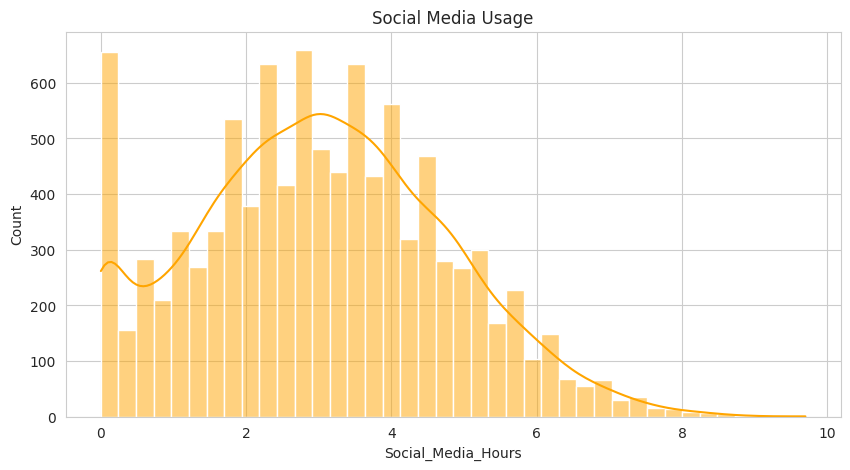

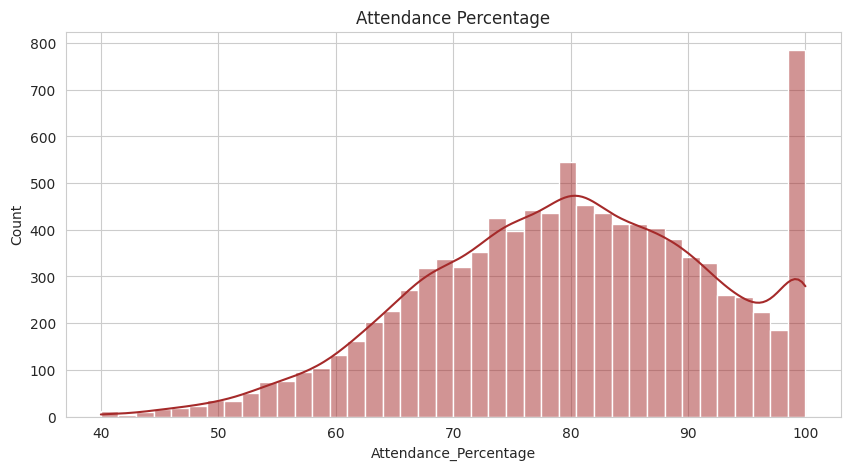

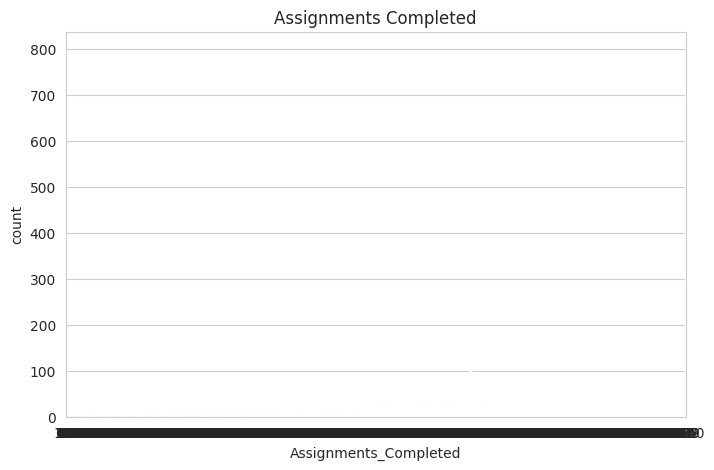

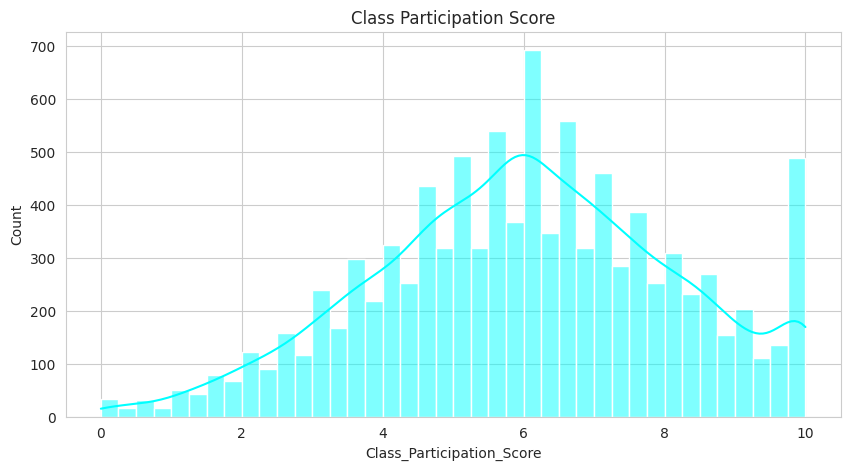

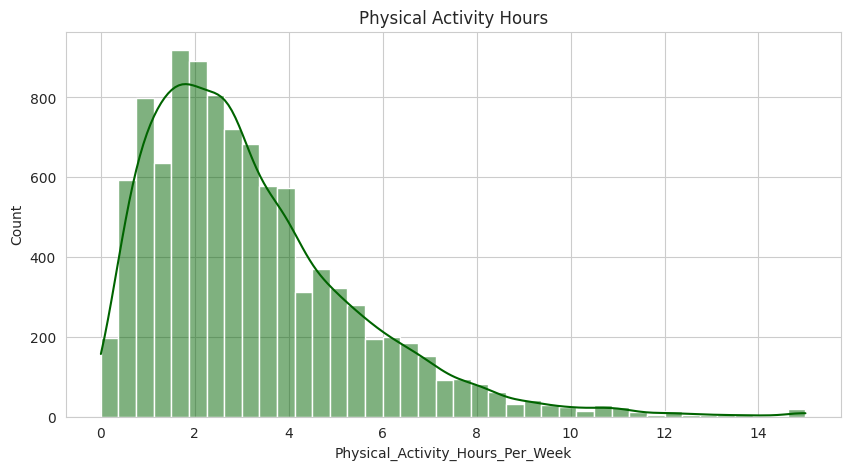

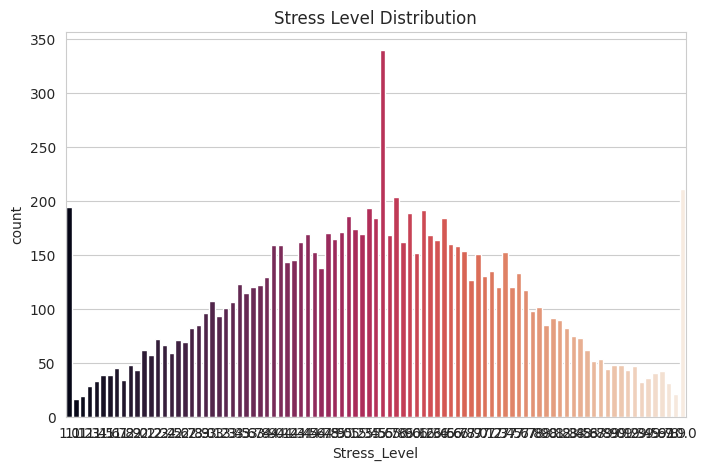

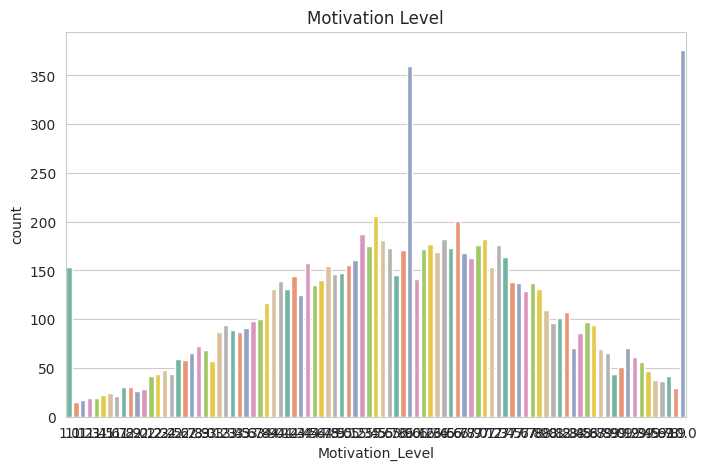

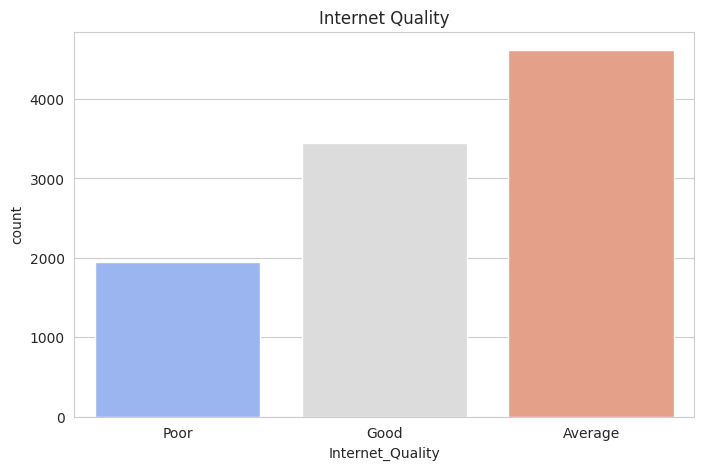

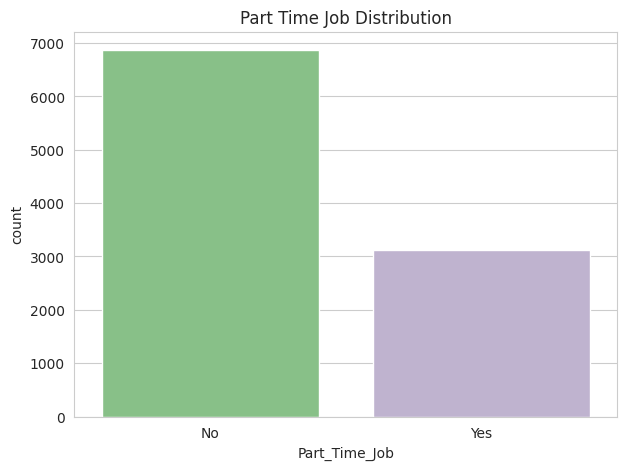

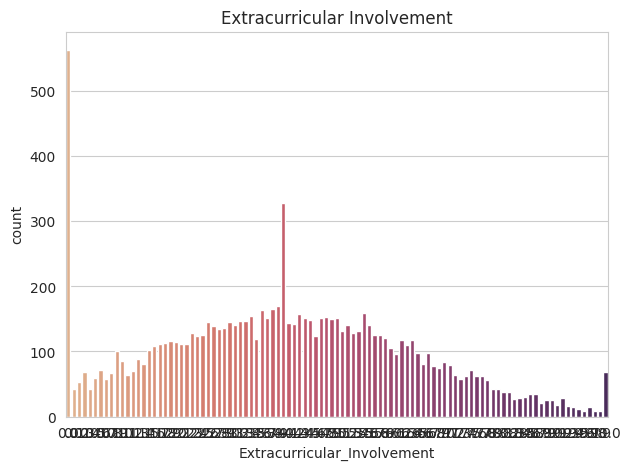

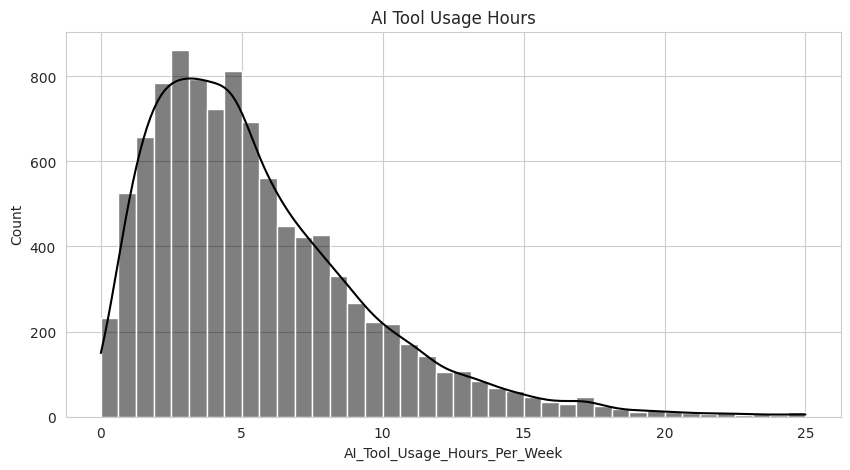

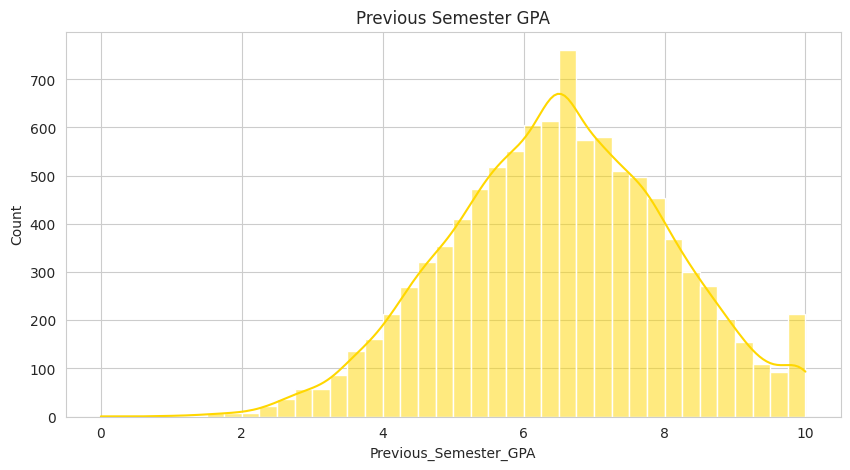

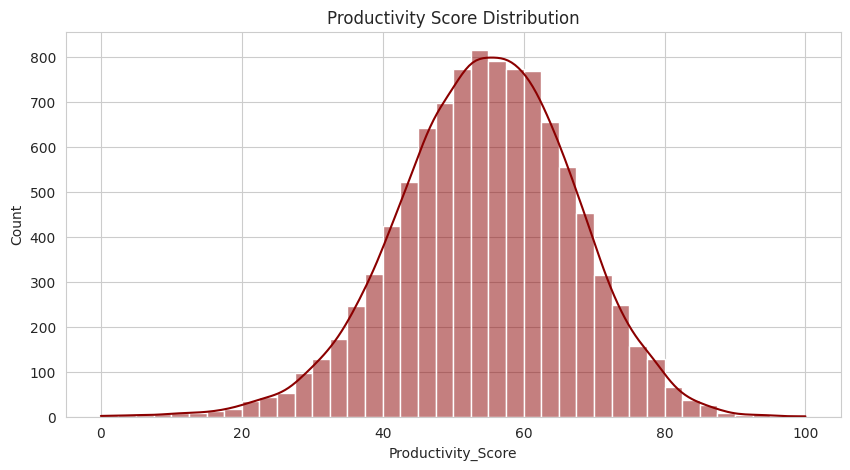

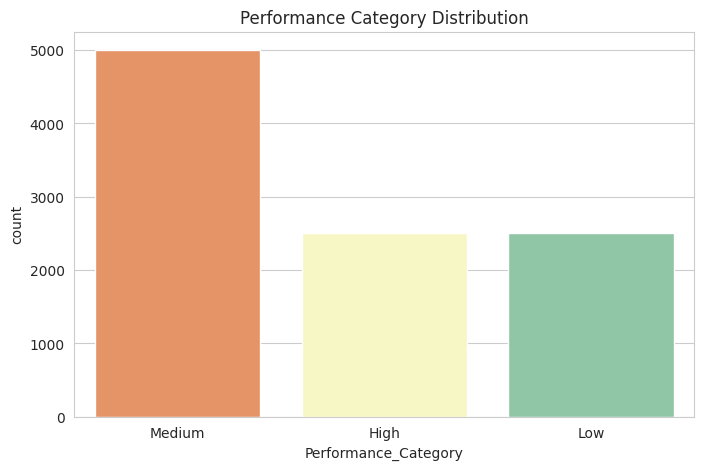

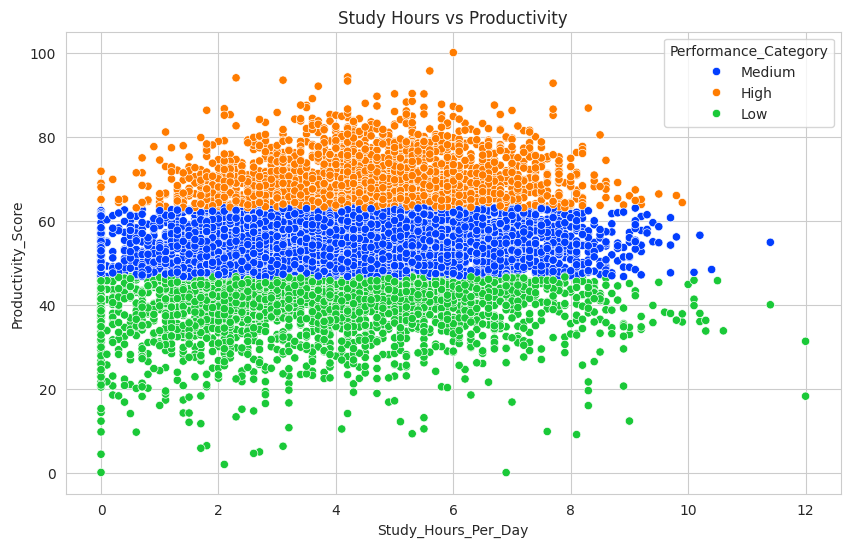

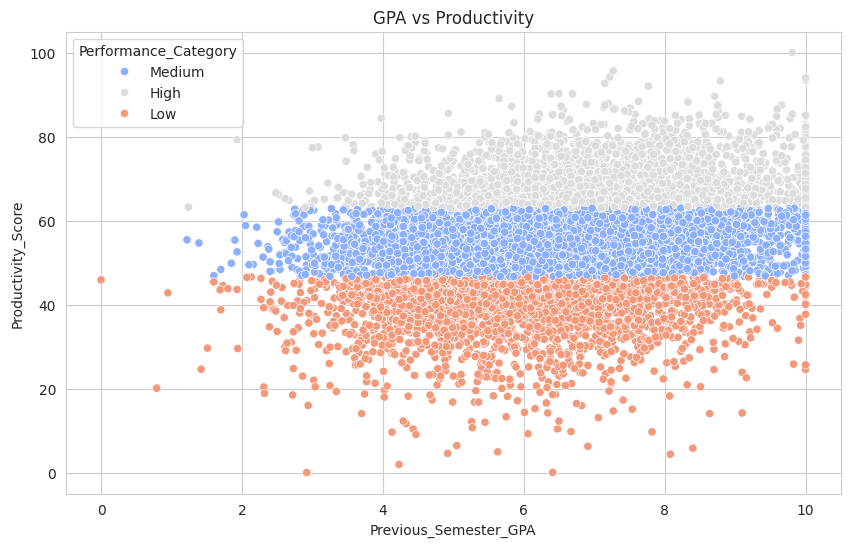

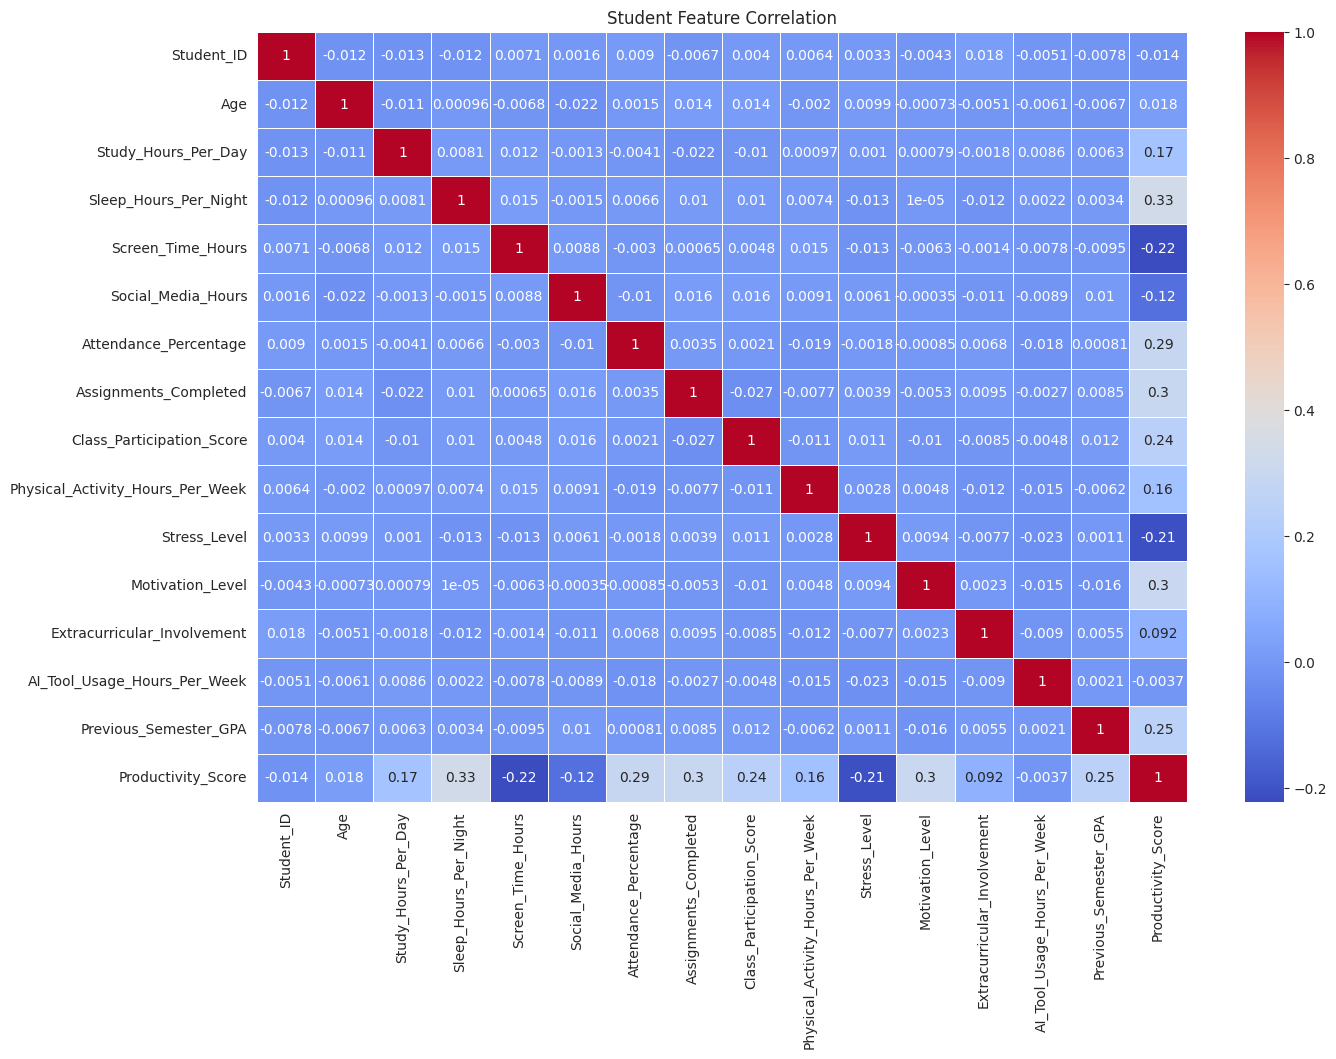

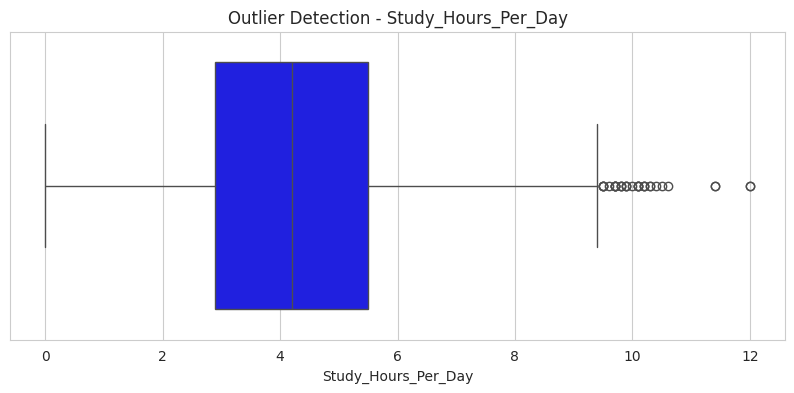

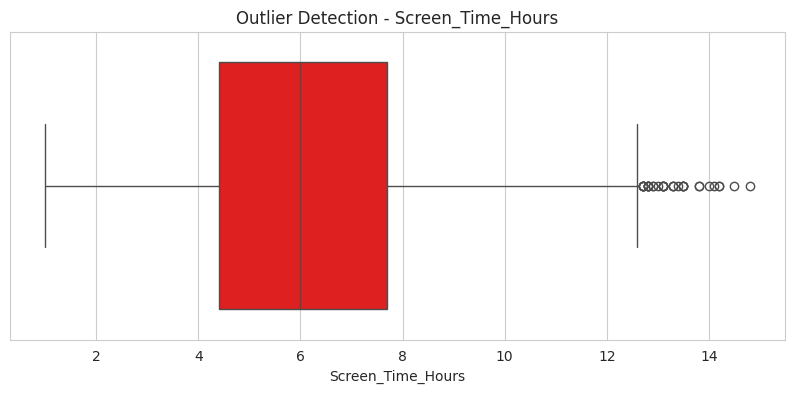

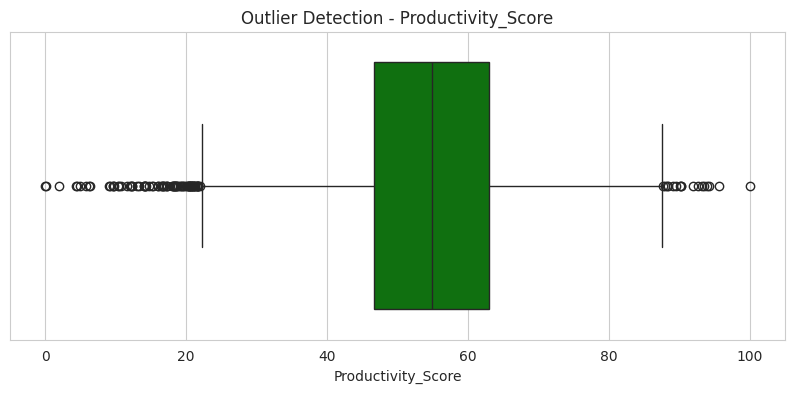

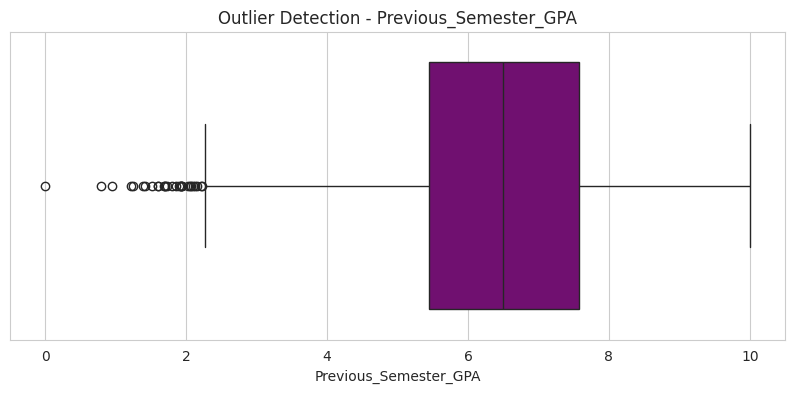

Student Performance Visualization Completed Successfully


In [11]:
sns.set_style("whitegrid")
# ============================================================
# 1. AGE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Age"],

bins=30,

kde=True,

color="blue"

)


plt.title(
"Student Age Distribution"
)


plt.show()







# ============================================================
# 2. GENDER COUNT
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

data=df,

x="Gender",

hue="Gender",

palette="viridis",

legend=False

)


plt.title(
"Gender Distribution"
)


plt.show()








# ============================================================
# 3. STUDY HOURS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Study_Hours_Per_Day"],

bins=40,

kde=True,

color="green"

)


plt.title(
"Daily Study Hours"
)


plt.show()








# ============================================================
# 4. SLEEP HOURS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Sleep_Hours_Per_Night"],

bins=40,

kde=True,

color="purple"

)


plt.title(
"Sleep Hours Distribution"
)


plt.show()








# ============================================================
# 5. SCREEN TIME
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Screen_Time_Hours"],

bins=40,

kde=True,

color="red"

)


plt.title(
"Screen Time Hours"
)


plt.show()








# ============================================================
# 6. SOCIAL MEDIA USAGE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Social_Media_Hours"],

bins=40,

kde=True,

color="orange"

)


plt.title(
"Social Media Usage"
)


plt.show()








# ============================================================
# 7. ATTENDANCE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Attendance_Percentage"],

bins=40,

kde=True,

color="brown"

)


plt.title(
"Attendance Percentage"
)


plt.show()








# ============================================================
# 8. ASSIGNMENTS COMPLETED
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

data=df,

x="Assignments_Completed",

hue="Assignments_Completed",

palette="magma",

legend=False

)


plt.title(
"Assignments Completed"
)


plt.show()








# ============================================================
# 9. CLASS PARTICIPATION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Class_Participation_Score"],

bins=40,

kde=True,

color="cyan"

)


plt.title(
"Class Participation Score"
)


plt.show()









# ============================================================
# 10. PHYSICAL ACTIVITY
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Physical_Activity_Hours_Per_Week"],

bins=40,

kde=True,

color="darkgreen"

)


plt.title(
"Physical Activity Hours"
)


plt.show()








# ============================================================
# 11. STRESS LEVEL
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

data=df,

x="Stress_Level",

hue="Stress_Level",

palette="rocket",

legend=False

)


plt.title(
"Stress Level Distribution"
)


plt.show()








# ============================================================
# 12. MOTIVATION LEVEL
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

data=df,

x="Motivation_Level",

hue="Motivation_Level",

palette="Set2",

legend=False

)


plt.title(
"Motivation Level"
)


plt.show()








# ============================================================
# 13. INTERNET QUALITY
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

data=df,

x="Internet_Quality",

hue="Internet_Quality",

palette="coolwarm",

legend=False

)


plt.title(
"Internet Quality"
)


plt.show()









# ============================================================
# 14. PART TIME JOB
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

data=df,

x="Part_Time_Job",

hue="Part_Time_Job",

palette="Accent",

legend=False

)


plt.title(
"Part Time Job Distribution"
)


plt.show()









# ============================================================
# 15. EXTRACURRICULAR
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(

data=df,

x="Extracurricular_Involvement",

hue="Extracurricular_Involvement",

palette="flare",

legend=False

)


plt.title(
"Extracurricular Involvement"
)


plt.show()







# ============================================================
# 16. AI TOOL USAGE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["AI_Tool_Usage_Hours_Per_Week"],

bins=40,

kde=True,

color="black"

)


plt.title(
"AI Tool Usage Hours"
)


plt.show()








# ============================================================
# 17. GPA ANALYSIS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Previous_Semester_GPA"],

bins=40,

kde=True,

color="gold"

)


plt.title(
"Previous Semester GPA"
)


plt.show()







# ============================================================
# 18. PRODUCTIVITY SCORE
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

df["Productivity_Score"],

bins=40,

kde=True,

color="darkred"

)


plt.title(
"Productivity Score Distribution"
)


plt.show()








# ============================================================
# 19. PERFORMANCE CATEGORY
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

data=df,

x="Performance_Category",

hue="Performance_Category",

palette="Spectral",

legend=False

)


plt.title(
"Performance Category Distribution"
)


plt.show()







# ============================================================
# 20. STUDY HOURS VS PRODUCTIVITY
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="Study_Hours_Per_Day",

y="Productivity_Score",

hue="Performance_Category",

palette="bright"

)


plt.title(
"Study Hours vs Productivity"
)


plt.show()








# ============================================================
# 21. GPA VS PRODUCTIVITY
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

data=df,

x="Previous_Semester_GPA",

y="Productivity_Score",

hue="Performance_Category",

palette="coolwarm"

)


plt.title(
"GPA vs Productivity"
)


plt.show()








# ============================================================
# 22. CORRELATION HEATMAP
# ============================================================


numeric=df.select_dtypes(
include=np.number
)



plt.figure(figsize=(15,10))


sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm",

linewidth=0.5

)


plt.title(
"Student Feature Correlation"
)


plt.show()








# ============================================================
# 23. OUTLIER DETECTION
# ============================================================


features=[

"Study_Hours_Per_Day",

"Screen_Time_Hours",

"Productivity_Score",

"Previous_Semester_GPA"

]


colors=[

"blue",

"red",

"green",

"purple"

]



for f,c in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[f],

        color=c

    )


    plt.title(
        f"Outlier Detection - {f}"
    )


    plt.show()







print(
"Student Performance Visualization Completed Successfully"
)

## Features Engineering 

Classes: ['High' 'Low' 'Medium']

Logistic Regression
Accuracy: 0.721
              precision    recall  f1-score   support

           0       0.77      0.66      0.71       500
           1       0.74      0.65      0.69       500
           2       0.70      0.79      0.74      1000

    accuracy                           0.72      2000
   macro avg       0.74      0.70      0.71      2000
weighted avg       0.73      0.72      0.72      2000


Decision Tree
Accuracy: 0.555
              precision    recall  f1-score   support

           0       0.51      0.53      0.52       500
           1       0.55      0.54      0.54       500
           2       0.58      0.57      0.58      1000

    accuracy                           0.56      2000
   macro avg       0.55      0.55      0.55      2000
weighted avg       0.56      0.56      0.56      2000


Random Forest
Accuracy: 0.6875
              precision    recall  f1-score   support

           0       0.83      0.48      0.61       

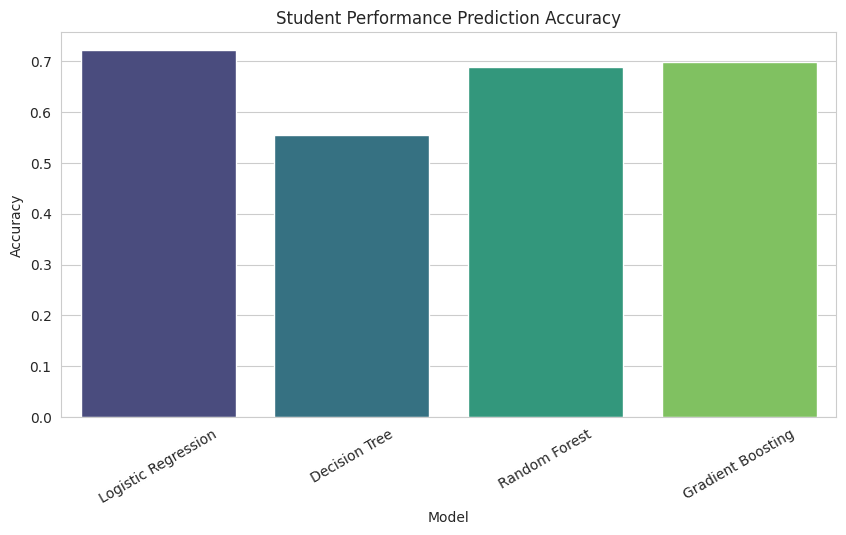

BEST MODEL: Logistic Regression


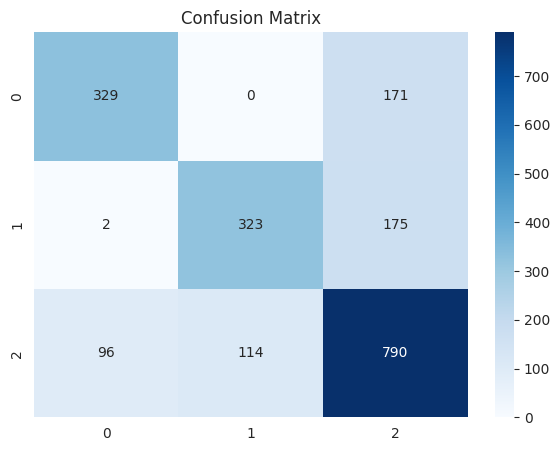

ROC AUC SCORE: 0.8746


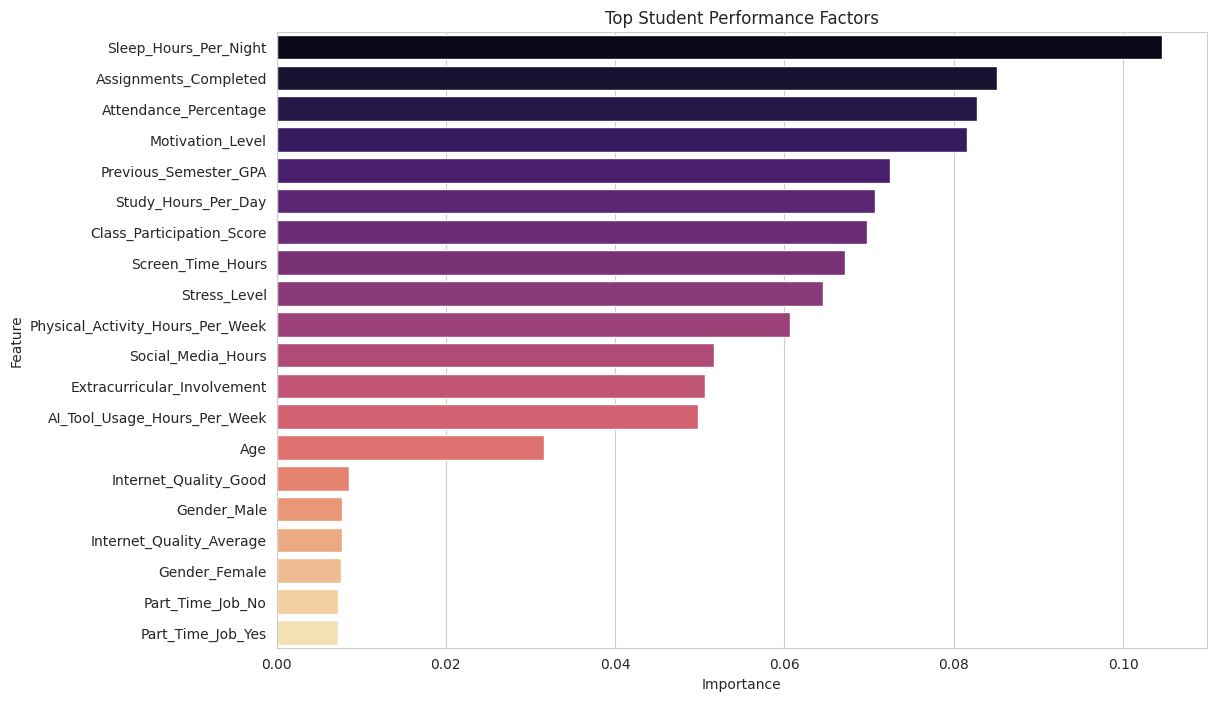


FINAL RESULTS
Logistic Regression : 0.721
Decision Tree : 0.555
Random Forest : 0.6875
Gradient Boosting : 0.6975
BEST MODEL: Logistic Regression
BEST ACCURACY: 0.721


In [12]:
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer



from sklearn.linear_model import LogisticRegression


from sklearn.tree import DecisionTreeClassifier



from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)



from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score

)

# ============================================================
# TARGET
# ============================================================


target="Performance_Category"



X=df.drop(

    target,

    axis=1

)



y=df[target]









# ============================================================
# REMOVE LEAKAGE / USELESS COLUMNS
# ============================================================


drop_cols=[


"Student_ID",


# because directly related to performance

"Productivity_Score"


]




X=X.drop(

columns=drop_cols,

errors="ignore"

)









# ============================================================
# TARGET LABEL ENCODING
# ============================================================


le=LabelEncoder()



y=le.fit_transform(

    y

)



print(

"Classes:",

le.classes_

)










# ============================================================
# TRAIN TEST SPLIT FIRST
# ============================================================



X_train,X_test,y_train,y_test=train_test_split(


    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)









# ============================================================
# COLUMN TYPES
# ============================================================


numeric_cols=X_train.select_dtypes(

include=np.number

).columns





categorical_cols=X_train.select_dtypes(

include="object"

).columns










# ============================================================
# NUMERIC PIPELINE
# ============================================================


numeric_pipe=Pipeline(

steps=[



(

"imputer",

SimpleImputer(

strategy="median"

)

),




(

"scaler",

StandardScaler()

)


]

)











# ============================================================
# CATEGORICAL PIPELINE
# ============================================================


categorical_pipe=Pipeline(

steps=[



(

"imputer",

SimpleImputer(

strategy="most_frequent"

)

),





(

"encoder",

OneHotEncoder(

handle_unknown="ignore"

)

)


]

)









# ============================================================
# PREPROCESSING
# ============================================================


preprocessor=ColumnTransformer(

transformers=[



(

"num",

numeric_pipe,

numeric_cols

),




(

"cat",

categorical_pipe,

categorical_cols

)



]

)









# ============================================================
# ML MODELS
# ============================================================



models={



"Logistic Regression":

LogisticRegression(

max_iter=1000

),






"Decision Tree":

DecisionTreeClassifier(

random_state=42

),






"Random Forest":

RandomForestClassifier(

n_estimators=200,

random_state=42,

n_jobs=-1

),







"Gradient Boosting":

GradientBoostingClassifier(

random_state=42

)



}









results={}

trained={}










# ============================================================
# MODEL TRAINING
# ============================================================


for name,model in models.items():



    print("\n====================")

    print(name)

    print("====================")




    pipe=Pipeline(

    steps=[



    (

    "preprocess",

    preprocessor

    ),




    (

    "model",

    model

    )



    ]

    )







    pipe.fit(

        X_train,

        y_train

    )







    pred=pipe.predict(

        X_test

    )








    acc=accuracy_score(

        y_test,

        pred

    )







    results[name]=acc

    trained[name]=pipe








    print(

    "Accuracy:",

    round(acc,4)

    )





    print(

    classification_report(

        y_test,

        pred

    )

    )











# ============================================================
# MODEL ACCURACY GRAPH
# ============================================================


acc_df=pd.DataFrame({


"Model":list(results.keys()),

"Accuracy":list(results.values())


})







plt.figure(figsize=(10,5))


sns.barplot(

data=acc_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)



plt.title(

"Student Performance Prediction Accuracy"

)



plt.xticks(rotation=30)


plt.show()











# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)



best_model=trained[

best_name

]





print(

"BEST MODEL:",

best_name

)










# ============================================================
# CONFUSION MATRIX
# ============================================================



best_pred=best_model.predict(

X_test

)





plt.figure(figsize=(7,5))


sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)



plt.title(

"Confusion Matrix"

)


plt.show()










# ============================================================
# ROC CURVE
# Binary + Multiclass supported
# ============================================================


prob=best_model.predict_proba(

X_test

)




if len(le.classes_)==2:



    fpr,tpr,_=roc_curve(

        y_test,

        prob[:,1]

    )



    auc=roc_auc_score(

        y_test,

        prob[:,1]

    )




else:


    auc=roc_auc_score(

        y_test,

        prob,

        multi_class="ovr"

    )





print(

"ROC AUC SCORE:",

round(auc,4)

)





if len(le.classes_)==2:


    plt.figure(figsize=(8,6))


    plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

    )



    plt.plot(

    [0,1],

    [0,1],

    "k--"

    )




    plt.xlabel(

    "False Positive Rate"

    )



    plt.ylabel(

    "True Positive Rate"

    )



    plt.title(

    "ROC Curve"

    )


    plt.legend()


    plt.show()











# ============================================================
# FEATURE IMPORTANCE
# ============================================================


rf=trained[

"Random Forest"

]






feature_names=(

list(numeric_cols)


+


list(

rf.named_steps["preprocess"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(

categorical_cols

)

)

)







importance=pd.DataFrame({


"Feature":feature_names,


"Importance":

rf.named_steps["model"]

.feature_importances_


})








importance=importance.sort_values(

"Importance",

ascending=False

)







plt.figure(figsize=(12,8))


sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)



plt.title(

"Top Student Performance Factors"

)


plt.show()










# ============================================================
# FINAL RESULT
# ============================================================


print("\nFINAL RESULTS")

print("====================")



for model,score in results.items():


    print(

        model,

        ":",

        round(score,4)

    )




print("====================")



print(

"BEST MODEL:",

best_name

)



print(

"BEST ACCURACY:",

round(max(results.values()),4)

)

## Thanks.........Please Upvote